# Lecture 6.5 — Agent Visualisation Tool for Debugging Multi-Agent Graphs

**Section 06 — Tracing, Observability & Capstone**

Every lecture in this section so far has looked at your agents **while they run**. This lecture is different. The tool you're about to use never makes an API call, never spends a token, and never runs your agents at all. It simply looks at the Python objects you've already built and draws a picture of them.

By the end of this notebook you will be able to:

- Install and use the optional `viz` dependency group
- Generate a visual graph of a single agent with tools using `draw_graph`
- Generate a graph of a multi-agent handoff system and see it recurse automatically
- Read the DOT source that `draw_graph` builds under the hood with `get_main_graph`
- Understand a genuine gotcha: `handoff()` objects and raw `Agent` objects produce **different graphs**, even when they behave identically at runtime
- Save a graph to a PNG file
- Use this tool as a debugging aid on the triage system from Lecture 5.5

## Cell 1: Install the SDK with the `viz` extra

This notebook installs the OpenAI Agents SDK the same way every notebook in this course does, with one difference: it adds the optional `viz` dependency group.

Agent visualisation depends on the `graphviz` Python package, which itself depends on the Graphviz system binary. That's a heavier, more specialised dependency than most learners need for the rest of the course, so the SDK keeps it **optional**. You only install it when you actually want to draw graphs, by adding `[viz]` in square brackets after the package name.

If you don't install this extra, `draw_graph` and `get_main_graph` simply aren't available, and importing them raises an `ImportError`.

**A note on the system binary:** Google Colab ships with the Graphviz system binary preinstalled, so the cell below is normally all you need. If you're running this notebook somewhere else and get an error mentioning that `dot` or `graphviz` can't be found, uncomment the `apt-get` line in the cell below to install it.

In [1]:
# Pinned for reproducibility. To use the latest version,
# run: pip install "openai-agents[viz]"
# Or substitute your preferred version below.
# The [viz] extra installs graphviz, required by draw_graph.
!pip install "openai-agents[viz]"==0.19.0 -q

# If graphviz is not found, uncomment the next line:
# !apt-get install -y graphviz -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 928.5/928.5 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.6/142.6 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.4/223.4 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 5.3 MB/s eta 0:00:00


## Cell 2: Set up your OpenAI API key

This cell configures your API key using Colab Secrets, the same method used throughout this course.

**To add your key in Colab:**

1. Click the key icon (🔑) in the left sidebar to open the Secrets panel.
2. Click **Add new secret**.
3. Set the name to `OPENAI_API_KEY` and paste your key as the value.
4. Toggle **Notebook access** on for this notebook.

The cell below reads that secret and writes it into the environment variable the SDK expects.

**A note for this lecture specifically:** this notebook doesn't make a single API call. Every agent you define is used only to build a picture of its structure. The key setup is still included so the notebook is self-contained and so you can experiment by running any of these agents yourself if you're curious what they'd actually say.

**Running locally instead of in Colab?** Set the environment variable in your terminal before launching Jupyter, for example `export OPENAI_API_KEY="sk-..."` on macOS or Linux, and skip the `userdata` call below.

In [2]:
import os
from google.colab import userdata

os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")

## Cell 3: Declare the model name

Every notebook in this course declares a single `MODEL_NAME` variable right after the API key cell, and every `Agent` in the notebook references it instead of hardcoding a model string. Change this one line and every agent below picks up the new model.

That matters less than usual in this particular lecture, since none of these agents are actually run. But we keep the pattern for consistency with the rest of the course, and so the agents are ready to run if you want to try them.

In [3]:
# See latest models at: https://platform.openai.com/docs/models
MODEL_NAME = "gpt-5.4-mini"

## Cell 4: Imports

All imports for this notebook live in one cell, consolidated up front.

| Import | Where it comes from | Why we need it |
|---|---|---|
| `Reasoning` | `openai.types.shared` | Configures reasoning effort on `ModelSettings`. Note this comes from the `openai` package, **not** from `agents`, a common mistake. |
| `Agent`, `ModelSettings`, `function_tool`, `handoff` | `agents` | The core building blocks: defining agents, tuning model behaviour, registering tools, and wrapping handoffs. |
| `draw_graph`, `get_main_graph` | `agents.extensions.visualization` | The two visualisation functions this lecture is about. |
| `RECOMMENDED_PROMPT_PREFIX` | `agents.extensions.handoff_prompt` | The suggested instruction prefix for agents that hand off, used later when we rebuild the Lecture 5.5 triage system. |

The two visualisation functions live in `agents.extensions.visualization`. This is the same `extensions` namespace pattern you've already seen with `handoff_filters` in Lecture 5.3 and `handoff_prompt` in Lecture 5.5. Anything that isn't part of the SDK's small core surface, but is still officially supported, tends to live under `agents.extensions`.

In [4]:
from openai.types.shared import Reasoning
from agents import Agent, ModelSettings, function_tool, handoff
from agents.extensions.visualization import (
    draw_graph,
    get_main_graph,
)
from agents.extensions.handoff_prompt import (
    RECOMMENDED_PROMPT_PREFIX,
)

## Understanding Agent Visualisation

Here's the official description of what this tool does:

> Agent visualization allows you to generate a structured graphical representation of agents and their relationships using Graphviz. This is useful for understanding how agents, tools, and handoffs interact within an application.

**The key framing for this lecture:** everything you've built in Section 6 so far, tracing in 6.1 to 6.3 and lifecycle hooks in 6.4, tells you what your system **did**. You had to run it to find out. Visualisation is the opposite. It inspects the Python object graph you've already built, agent by agent, tool by tool, handoff by handoff, and draws it. No API calls, no tokens, no runtime.

| Tool | Answers |
|---|---|
| Tracing (6.1–6.3) | What did my system do? |
| Lifecycle hooks (6.4) | What ran at each step? |
| Visualisation (6.5, this lecture) | What does my system look like? |

### The visual encoding

Every graph `draw_graph` produces uses the same legend:

| Element | Shape | Colour | Meaning |
|---|---|---|---|
| Agent | Rectangle | Yellow | An `Agent` instance |
| Tool | Ellipse | Green | A function tool the agent can call |
| MCP server | Rectangle | Grey | An MCP server attached to the agent |
| `__start__` | Ellipse | Light blue | Entry point of the graph |
| `__end__` | Ellipse | Light blue | An agent with no handoffs, where a conversation can terminate |
| Handoff edge | Solid arrow | — | Agent-to-agent handoff |
| Tool edge | Dotted arrow | — | Tool invocation (drawn both directions) |
| MCP edge | Dashed arrow | — | MCP server invocation (drawn both directions) |

You won't see any grey MCP boxes in this notebook. MCP servers are covered in a later update section, and drawing one here would require running an external server process for no visual payoff. Just know the grey box exists in the legend for when you get there.

**One Colab-specific detail before we start:** `draw_graph` only renders inline when it is the **last expression** in the cell. Write `draw_graph(agent)` on its own, not wrapped in `print()`. Wrapping it in `print()` prints the Python object's repr as text and shows no image at all.

## Cell 5: A simple agent with tools — your first graph

Time to draw something. This cell defines a single agent with two function tools and no handoffs, then calls `draw_graph` on it.

`get_weather` and `get_time` are ordinary `@function_tool` functions, exactly like the ones from Section 3. `simple_agent` registers both of them in its `tools` list and nothing else new is happening in its definition. The only new line is the last one: `draw_graph(simple_agent)`.

Because it's the last expression in the cell, Colab renders the returned `graphviz.Source` object as an inline image instead of printing its repr.

**What to look for once it renders:**

- A light blue `__start__` node with a solid arrow into the yellow `Weather Assistant` box
- Two green tool ellipses, `get_weather` and `get_time`, each connected to the agent by a **pair** of dotted arrows, one in each direction
- A solid arrow from `Weather Assistant` to a light blue `__end__` node

That `__end__` arrow isn't decorative. Looking at the SDK source, it's added with `if not agent.handoffs`, meaning any agent with an empty `handoffs` list gets routed straight to `__end__`. `simple_agent` never hands off to anyone, so this is where its conversation terminates.

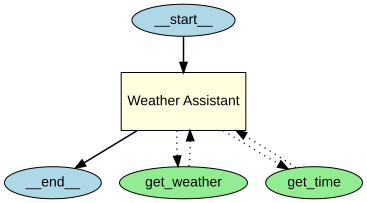

In [5]:
@function_tool
def get_weather(city: str) -> str:
    """Returns the current weather for a city.

    Args:
        city: The city to check.
    """
    return f"The weather in {city} is sunny."


@function_tool
def get_time(city: str) -> str:
    """Returns the current local time for a city.

    Args:
        city: The city to check.
    """
    return f"The current time in {city} is 14:35."


simple_agent = Agent(
    name="Weather Assistant",
    instructions="You help users with weather and time.",
    model=MODEL_NAME,
    model_settings=ModelSettings(
        reasoning=Reasoning(effort="none"),
        verbosity="low",
    ),
    tools=[get_weather, get_time],
)

draw_graph(simple_agent)

## Cell 6: Multi-agent handoffs — watch the graph recurse

You saw a single agent's graph. Now let's see what happens when that agent hands off to others.

This cell defines three agents. `spanish_agent` and `english_agent` are simple leaf agents, and `english_agent` additionally carries its own `get_weather` tool. `triage_agent` sits above both of them and passes `handoffs=[spanish_agent, english_agent]`, a list of raw `Agent` objects, exactly the pattern taught in Lecture 5.2. `triage_agent` also carries its own `get_time` tool. The last line draws the graph starting from `triage_agent`.

Run it and look closely at what appears.

**What to look for:**

- `Triage Agent` connects to both `Spanish Agent` and `English Agent` with solid handoff arrows
- `Triage Agent`'s own `get_time` tool appears, dotted, bidirectional, exactly like Cell 5
- `English Agent`'s `get_weather` tool **also appears**, attached to `English Agent`, not to `Triage Agent`, even though you never mentioned that tool anywhere near the triage level
- `Spanish Agent` has no handoffs of its own, so it gets its own `__end__` arrow. `English Agent` does too.

Here's the part worth sitting with: you called `draw_graph` exactly once, on `triage_agent`. Everything else on the page, both specialist agents and the tool buried inside one of them, was discovered automatically. That's because passing a raw `Agent` object inside `handoffs=[]` causes the visualisation function to recurse into it and map its tools and handoffs too. One function call gave you the full system topology.

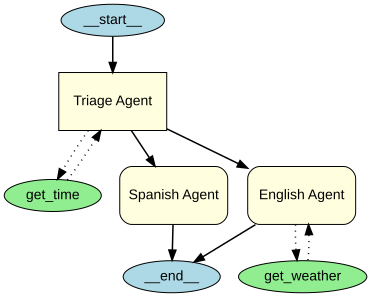

In [6]:
spanish_agent = Agent(
    name="Spanish Agent",
    instructions="You only speak Spanish.",
    model=MODEL_NAME,
    model_settings=ModelSettings(
        reasoning=Reasoning(effort="none"),
        verbosity="low",
    ),
)

english_agent = Agent(
    name="English Agent",
    instructions="You only speak English.",
    model=MODEL_NAME,
    model_settings=ModelSettings(
        reasoning=Reasoning(effort="none"),
        verbosity="low",
    ),
    tools=[get_weather],
)

triage_agent = Agent(
    name="Triage Agent",
    instructions=(
        "Handoff to the appropriate agent based on the "
        "language of the request."
    ),
    model=MODEL_NAME,
    model_settings=ModelSettings(
        reasoning=Reasoning(effort="none"),
        verbosity="low",
    ),
    handoffs=[spanish_agent, english_agent],
    tools=[get_time],
)

draw_graph(triage_agent)

## Cell 7: `get_main_graph()` — the DOT source behind the picture

`draw_graph` is a thin wrapper around two things: a function that builds a plain text description of the graph, and Graphviz, which turns that text into a picture. This cell exposes the text.

`get_main_graph` takes the same agent `draw_graph` would take, and returns a string in DOT format, the plain-text language Graphviz reads. This cell captures that string in `dot_source` and prints it directly instead of rendering it as an image.

**What to look for in the printed output:**

- `"__start__" -> "Triage Agent";` near the top, the entry point edge
- `style=dotted` on the lines connecting `Triage Agent` to `get_time`, and `English Agent` to `get_weather`
- Plain solid arrows, no style attribute at all, on the handoff lines from `Triage Agent` to each specialist
- `"Spanish Agent" -> "__end__";` and `"English Agent" -> "__end__";`, one line each, since neither specialist hands off further

This is your debugging tool for the debugging tool. When a rendered graph surprises you, whether a node is missing or an arrow points somewhere unexpected, don't guess. Print the DOT source and read exactly which nodes and edges the function actually generated. The answer is always in there.

In [7]:
dot_source = get_main_graph(triage_agent)
print(dot_source)


    digraph G {
        graph [splines=true];
        node [fontname="Arial"];
        edge [penwidth=1.5];
    "__start__" [label="__start__", shape=ellipse, style=filled, fillcolor=lightblue, width=0.5, height=0.3];"__end__" [label="__end__", shape=ellipse, style=filled, fillcolor=lightblue, width=0.5, height=0.3];"Triage Agent" [label="Triage Agent", shape=box, style=filled, fillcolor=lightyellow, width=1.5, height=0.8];"get_time" [label="get_time", shape=ellipse, style=filled, fillcolor=lightgreen, width=0.5, height=0.3];"Spanish Agent" [label="Spanish Agent", shape=box, style="filled,rounded", fillcolor=lightyellow, width=1.5, height=0.8];"English Agent" [label="English Agent", shape=box, style="filled,rounded", fillcolor=lightyellow, width=1.5, height=0.8];"get_weather" [label="get_weather", shape=ellipse, style=filled, fillcolor=lightgreen, width=0.5, height=0.3];"__start__" -> "Triage Agent";
        "Triage Agent" -> "get_time" [style=dotted, penwidth=1.5];
        "get_time"

## Cell 8: The gotcha, part one — raw `Agent` objects in `handoffs`

Lecture 5.2 taught you two equivalent ways to write a handoff: pass a raw `Agent` object directly, or wrap it with `handoff()`. Both route the conversation identically at runtime. This cell and the next one build two structurally identical systems, one using each form, so you can see whether "identical at runtime" also means "identical on the page."

This is version A. `specialist_a` is a leaf agent with its own `get_weather` tool. `triage_raw` hands off to it using a raw `Agent` object in its `handoffs` list, the same pattern as Cell 6. The cell prints the DOT source directly so you can read the node and edge list before you see the picture.

Run it and check the printed output for a node line naming `get_weather` and a pair of dotted edges connecting it to `Specialist A`.

In [8]:
# Version A: raw Agent object in handoffs
specialist_a = Agent(
    name="Specialist A",
    instructions="You are a specialist.",
    model=MODEL_NAME,
    model_settings=ModelSettings(
        reasoning=Reasoning(effort="none"),
        verbosity="low",
    ),
    tools=[get_weather],
)

triage_raw = Agent(
    name="Triage Raw",
    instructions="Route to the specialist.",
    model=MODEL_NAME,
    model_settings=ModelSettings(
        reasoning=Reasoning(effort="none"),
        verbosity="low",
    ),
    handoffs=[specialist_a],
)

print("Version A — raw Agent in handoffs:")
print(get_main_graph(triage_raw))

Version A — raw Agent in handoffs:

    digraph G {
        graph [splines=true];
        node [fontname="Arial"];
        edge [penwidth=1.5];
    "__start__" [label="__start__", shape=ellipse, style=filled, fillcolor=lightblue, width=0.5, height=0.3];"__end__" [label="__end__", shape=ellipse, style=filled, fillcolor=lightblue, width=0.5, height=0.3];"Triage Raw" [label="Triage Raw", shape=box, style=filled, fillcolor=lightyellow, width=1.5, height=0.8];"Specialist A" [label="Specialist A", shape=box, style="filled,rounded", fillcolor=lightyellow, width=1.5, height=0.8];"get_weather" [label="get_weather", shape=ellipse, style=filled, fillcolor=lightgreen, width=0.5, height=0.3];"__start__" -> "Triage Raw";
            "Triage Raw" -> "Specialist A";
        "Specialist A" -> "get_weather" [style=dotted, penwidth=1.5];
        "get_weather" -> "Specialist A" [style=dotted, penwidth=1.5];"Specialist A" -> "__end__";}


## Cell 9: The gotcha, part two — `handoff()` objects in `handoffs`

Now the second version. `specialist_b` is built identically to `specialist_a`, same instructions, same `get_weather` tool. The only difference in the whole system is one word: `triage_wrapped` hands off to `specialist_b` using `handoff(specialist_b)` instead of the bare `specialist_b`.

Same routing behaviour at runtime. Same specialist, same tool. Run this cell and compare its printed DOT source to Cell 8's, line by line.

Watch for what's missing this time. There should be no node line for `get_weather` anywhere in this output, and no dotted edges at all.

In [9]:
# Version B: handoff() object in handoffs
specialist_b = Agent(
    name="Specialist B",
    instructions="You are a specialist.",
    model=MODEL_NAME,
    model_settings=ModelSettings(
        reasoning=Reasoning(effort="none"),
        verbosity="low",
    ),
    tools=[get_weather],
)

triage_wrapped = Agent(
    name="Triage Wrapped",
    instructions="Route to the specialist.",
    model=MODEL_NAME,
    model_settings=ModelSettings(
        reasoning=Reasoning(effort="none"),
        verbosity="low",
    ),
    handoffs=[handoff(specialist_b)],
)

print("Version B — handoff() object in handoffs:")
print(get_main_graph(triage_wrapped))

Version B — handoff() object in handoffs:

    digraph G {
        graph [splines=true];
        node [fontname="Arial"];
        edge [penwidth=1.5];
    "__start__" [label="__start__", shape=ellipse, style=filled, fillcolor=lightblue, width=0.5, height=0.3];"__end__" [label="__end__", shape=ellipse, style=filled, fillcolor=lightblue, width=0.5, height=0.3];"Triage Wrapped" [label="Triage Wrapped", shape=box, style=filled, fillcolor=lightyellow, width=1.5, height=0.8];"Specialist B" [label="Specialist B", shape=box, style="filled,rounded", fillcolor=lightyellow, width=1.5, height=0.8];"__start__" -> "Triage Wrapped";
            "Triage Wrapped" -> "Specialist B";}


## Cell 10: Drawing version A

Time to see version A as a picture instead of text. This cell draws `triage_raw`, the raw `Agent` version from Cell 8.

**What to look for:** `Specialist A` should appear as a yellow box, with a green `get_weather` ellipse attached to it by dotted arrows, and `Specialist A` should have its own `__end__` arrow.

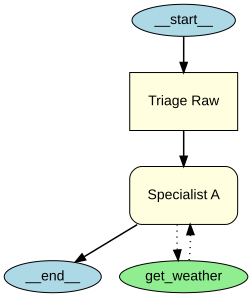

In [10]:
draw_graph(triage_raw)

## Cell 11: Drawing version B

Now the same thing for version B, drawing `triage_wrapped` from Cell 9.

**What to look for, side by side with Cell 10:** `Specialist B` still appears as a yellow box, because the code always draws a node for a handoff target's name, whether it's a raw `Agent` or a wrapped `Handoff`. But that's where it stops. No green tool ellipse. No dotted arrows. No `__end__` arrow either, since `Specialist B` was never actually visited to check whether it has handoffs of its own.

Here's the part that actually matters. Both systems behave identically the moment you run them. `Runner.run(triage_raw, ...)` and `Runner.run(triage_wrapped, ...)` would hand off to their specialist the same way, call the same tool, return the same kind of answer. But the picture you get from `draw_graph` is not the same, because the SDK source treats these two forms differently. Looking at `get_all_nodes` and `get_all_edges` in `agents/extensions/visualization.py`: when the handoff target is a raw `Agent` instance, the function recurses into it, walking its tools and handoffs and adding all of that to the graph. When the handoff target is a `Handoff` instance, the kind you get back from calling `handoff(...)`, the function draws one box for it and stops. No recursion, no tools, no further handoffs.

If your graph ever looks thinner than you know your system to be, this is almost always why. Check whether you wrapped that handoff in `handoff()`. If you want the complete picture, pass raw `Agent` objects wherever you can.

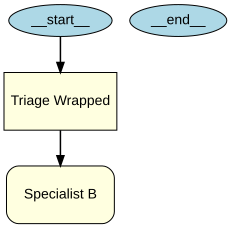

In [11]:
draw_graph(triage_wrapped)

## Cell 12: Saving the graph to a file

Every graph so far has rendered inline in the notebook. `draw_graph` can also save the picture as a PNG, by passing a `filename` argument.

This cell draws `triage_agent` from Cell 6 again, this time with `filename="agent_graph"` set. Note there's no file extension on that string. Looking at the source, `draw_graph` calls `graph.render(filename, format="png", cleanup=True)` internally, and the `format="png"` argument is what appends `.png` for you. The `cleanup=True` argument removes the intermediate DOT file Graphviz generates on disk, leaving just the PNG behind.

Run this cell, then check the file browser panel on the left side of Colab. You should see `agent_graph.png` appear in the file list, and you can download it from there.

**Why this matters in practice:** a PNG of your agent topology is something you can commit to a repository, paste into a design doc, or drop into a Slack message. It lets a teammate see the shape of your system without running any code at all.

In [12]:
draw_graph(triage_agent, filename="agent_graph")
print("Saved as agent_graph.png in the working directory.")

Saved as agent_graph.png in the working directory.


## A Warning About `.view()`

The official documentation shows one more way to display a graph:

```python
draw_graph(triage_agent).view()
```

By default, `draw_graph` displays the graph inline. Calling `.view()` on the returned object instead opens the image in a separate window, using your operating system's default image viewer.

**This will not work in Google Colab**, and there's no code cell for it in this notebook because of that. Colab runs your notebook on a remote server with no display attached, so there is no window for `.view()` to open. Calling it here will either raise an error or silently do nothing, depending on your Colab environment.

If you're running this notebook on your own machine outside Colab, `.view()` works exactly as documented. Inside Colab, stick to inline rendering, which you've been using all notebook, or save to a file with `filename=`, which you just did in Cell 12.

## Cell 13: Visualising the Lecture 5.5 triage system — the real payoff

Lecture 5.5 spent an entire lecture building a support triage system: a triage agent routing to two specialists, each specialist owning its own domain tool, and each specialist handing back to triage using `agent.handoffs.append(handoff(...))` so the conversation could return for further routing.

This cell rebuilds a simplified version of that system. `billing_agent` and `tech_agent` each get their own tool and use `RECOMMENDED_PROMPT_PREFIX` in their instructions, exactly as in 5.5. `support_triage` hands off to both using `handoff(...)`, matching the real pattern from that lecture. Then, matching the bidirectional pattern from 5.5, each specialist's `handoffs` list gets a return handoff back to `support_triage` appended after all three agents exist.

Run it and look at the picture. Then read the paragraph below before you conclude anything about what's missing.

**What actually renders:**

- Solid arrows from `Support Triage` to both `Billing Agent` and `Tech Agent`
- No tool ellipses anywhere. `check_invoice` and `restart_service` are nowhere on the page.
- No arrows pointing back from either specialist to `Support Triage`. The return handoff you registered with `.handoffs.append(...)` is completely invisible here.

Here's the thing that trips people up if you skip it. Lecture 5.5's routing, in both directions, was built entirely out of `handoff(...)` calls, not raw `Agent` objects. You already know from Cell 11 what that means for the specialist boxes themselves: no recursion, no tools. What's less obvious is that it also blocks the return path. `get_all_edges` only recurses into an agent when it receives that agent as a raw `Agent` instance. `Support Triage` never receives `billing_agent` or `tech_agent` that way, so the function never looks inside either specialist to find the return handoff you appended. The loop you built in code is real. The loop you can see in this picture is not.

The `visited` set in `get_all_edges` and `get_all_nodes` exists precisely to stop that kind of cycle from recursing forever, but it only comes into play when recursion is actually happening, which means raw `Agent` objects all the way around the loop. Wrap any leg of a circular handoff chain in `handoff(...)`, as 5.5 correctly does for its tool-naming control, and the picture simply stops at that edge instead of looping.

That's your anchor point for the rest of the notebook. A visualisation is a map of what the code would recurse into, not a guarantee that everything you wired up is on the page. For the full picture of a system built with `handoff()` objects, print the DOT source with `get_main_graph` and read the object graph yourself, the way you did in Cell 7. That's still the most complete answer you have, and it's one function call away.

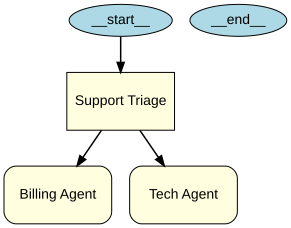

In [13]:
@function_tool
def check_invoice(invoice_id: str) -> str:
    """Looks up the status of a billing invoice.

    Args:
        invoice_id: The invoice identifier to check.
    """
    return f"Invoice {invoice_id} is paid in full."


@function_tool
def restart_service(service_name: str) -> str:
    """Restarts a named service for the customer.

    Args:
        service_name: The service to restart.
    """
    return f"Service {service_name} has been restarted."


billing_agent = Agent(
    name="Billing Agent",
    instructions=(
        f"{RECOMMENDED_PROMPT_PREFIX}\n"
        "You handle billing questions. If the request is not "
        "about billing, hand off back to Support Triage."
    ),
    model=MODEL_NAME,
    model_settings=ModelSettings(
        reasoning=Reasoning(effort="none"),
        verbosity="low",
    ),
    tools=[check_invoice],
)

tech_agent = Agent(
    name="Tech Agent",
    instructions=(
        f"{RECOMMENDED_PROMPT_PREFIX}\n"
        "You handle technical support questions. If the request "
        "is not technical, hand off back to Support Triage."
    ),
    model=MODEL_NAME,
    model_settings=ModelSettings(
        reasoning=Reasoning(effort="none"),
        verbosity="low",
    ),
    tools=[restart_service],
)

support_triage = Agent(
    name="Support Triage",
    instructions=(
        f"{RECOMMENDED_PROMPT_PREFIX}\n"
        "Route billing questions to Billing Agent and technical "
        "questions to Tech Agent."
    ),
    model=MODEL_NAME,
    model_settings=ModelSettings(
        reasoning=Reasoning(effort="none"),
        verbosity="low",
    ),
    handoffs=[handoff(billing_agent), handoff(tech_agent)],
)

# Specialists hand back to triage, same bidirectional pattern as Lecture 5.5
billing_agent.handoffs.append(handoff(support_triage))
tech_agent.handoffs.append(handoff(support_triage))

draw_graph(support_triage)

## Reading the Graph as a Debugging Tool

A quick reference for interpreting what you see on the page.

| What you see | What it means |
|---|---|
| An agent you expected to see is missing from the graph entirely | This tool can't draw what it never reached. Only one agent ever gets a `__start__` arrow, the root you called `draw_graph` on, so a genuinely unreachable agent just won't appear at all. Check whether it's nested behind a `handoff()` object. See Cell 11. |
| An agent with an `__end__` edge | It has no handoffs. It terminates the conversation. |
| A tool ellipse attached to the wrong agent | The tool is registered on the wrong agent definition. |
| A missing agent you expected to see | Likely wrapped in `handoff()`, so the graph did not recurse into it. See Cell 11. |
| No dotted arrows at all | No function tools registered on that agent. |
| A one-way handoff where you wanted two-way | Either the return handoff is missing from your code, or it's there but wrapped in `handoff()`, which the graph never recurses into to find it. See Cell 13. |

And a quick guide to which Section 6 tool answers which question:

| Question | Tool |
|---|---|
| What does my system look like? | `draw_graph` (this lecture, 6.5) |
| What did my system actually do? | Traces dashboard (6.2) |
| Why is this agent unreachable? | `draw_graph` (this lecture, 6.5) |
| Why was this run slow? | Traces dashboard (6.2) |
| What ran at each lifecycle event? | Hooks (6.4) |

You now have every tool in Section 6's observability toolkit: tracing for what happened, hooks for what ran at each step, and visualisation for what the system is shaped like before any of it runs. The capstone in 6.6 is where all three, plus everything from Sections 1 through 5, come together in one project.